# 02 - Deep Knowledge Tracing (DKT) - LSTM

## Proyecto Lairn - Microservicio de Knowledge Tracing

Este notebook implementa **Deep Knowledge Tracing** (Piech et al. 2015) como evolucion del baseline BKT. Lo entrenamos sobre las **mismas dos fuentes de datos** (sintetico++ y ASSISTments real) para poder COMPARAR contra el BKT del notebook anterior.

### Diferencias con BKT

| | BKT (01_bkt.ipynb) | DKT (este notebook) |
|---|--------------------|---------------------|
| **Arquitectura** | HMM 2-estados por skill | LSTM unica para todos los skills |
| **Parametros** | 4 por skill (~12 total) | ~5.000-50.000 (pesos LSTM) |
| **Dependencias entre skills** | No | Si (las descubre solo) |
| **Olvido (forgetting)** | No (BKT clasico) | Si (LSTM puede olvidar) |
| **AUC esperado ASSISTments** | 0.67-0.73 | **0.80-0.86** (Piech 2015) |

### Buenas practicas aplicadas (las mismas que BKT)

1. Split por estudiante (no por interaccion) -> evita data leakage
2. `random_state=42` en numpy Y torch (reproducibilidad total)
3. Validacion de datos antes de entrenar
4. Constantes al inicio (sin numeros magicos)
5. Funciones con docstrings
6. Persistencia de modelo + metricas + config
7. Evaluacion cruzada sobre ambas fuentes de datos

## 1️ Setup inicial

Cargamos PyTorch (la librería de redes neuronales), nuestro modelo DKT (`src/dkt_modelo.DKTModel`) y también importamos BKT (para comparar).

**¿Por qué PyTorch?** Es la librería más usada para redes neuronales en investigación. En este proyecto usamos solo CPU (sin GPU); es suficiente para nuestros datos (~30k-80k filas).


In [1]:
# ============================================================================
# CELDA 1 - IMPORTS Y CONFIGURACION GLOBAL
# ============================================================================

# sys para path, os para env, json/pickle para serializacion
import sys
import os
import json
import pickle
from pathlib import Path

# numpy y pandas (siempre)
import numpy as np
import pandas as pd
# matplotlib y seaborn para graficas
import matplotlib.pyplot as plt
import seaborn as sns

# train_test_split y metricas de sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, mean_squared_error

# Agregamos la raiz del proyecto al path
ROOT = next((p for p in [Path('.').resolve(), *Path('.').resolve().parents] if (p / 'artefactos').exists()), Path('.').resolve())
sys.path.insert(0, str(ROOT))

# Importamos generador, BKT (para comparacion) y DKT
from ml.datos.generador_datos import generar_dataset, guardar_dataset
from ml.modelos.bkt import BKTModel
from ml.modelos.dkt import DKTModel

# PyTorch (lo importamos aqui solo para fijar la semilla globalmente)
import torch

# Estilo visual
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print('[OK] Imports DKT cargados (PyTorch ' + torch.__version__ + ')')

[OK] Imports DKT cargados (PyTorch 2.12.0+cpu)


In [2]:
# ============================================================================
# CELDA 2 - CONSTANTES CONFIGURABLES
# ============================================================================

# --- Semilla global ---
SEED = 42

# --- FUENTE DE DATOS ---
# 'sintetico' o 'real' (ASSISTments). El notebook evalua AMBAS al final.
FUENTE_DATOS = 'sintetico'

# --- Configuracion del dataset sintetico ---
N_ESTUDIANTES = 1000
CONCEPTOS_SINTETICOS = ['derivada_seno', 'derivada_coseno', 'regla_cadena']
MIN_INTERACCIONES = 5
MAX_INTERACCIONES = 15

# --- Configuracion del dataset real ---
TOP_K_SKILLS_REAL = 10

# --- Split train/test ---
TEST_SIZE = 0.30

# --- Hiperparametros DKT ---
HIDDEN_DIM = 64        # dimension del estado oculto LSTM
NUM_LAYERS = 1         # capas LSTM apiladas
DROPOUT = 0.2          # regularizacion entre capas (solo si NUM_LAYERS>1)
N_EPOCHS = 30          # epocas de entrenamiento
BATCH_SIZE = 32        # secuencias por batch
LEARNING_RATE = 1e-3   # tasa de aprendizaje Adam
MAX_LEN = 200          # longitud maxima de secuencia (trunca / padea)

# --- Umbral de dominio ---
UMBRAL_DOMINIO = 0.80

# --- Rutas de salida ---
RUTA_DATASET = ROOT / 'ml' / 'datos' / 'interacciones.csv'
CARPETA_MODELO = ROOT / 'artefactos' / f'dkt_{FUENTE_DATOS}'
RUTA_MODELO = CARPETA_MODELO / 'model.pkl'
RUTA_METRICAS = CARPETA_MODELO / 'metrics.json'
RUTA_CONFIG = CARPETA_MODELO / 'config.json'

# Crear carpeta de salida
CARPETA_MODELO.mkdir(parents=True, exist_ok=True)

# Resumen
print(f'[CONFIG] Fuente de datos: {FUENTE_DATOS.upper()}')
print(f'   - Semilla: {SEED}')
print(f'   - DKT: hidden_dim={HIDDEN_DIM}, layers={NUM_LAYERS}, dropout={DROPOUT}')
print(f'   - Entrenamiento: epochs={N_EPOCHS}, batch={BATCH_SIZE}, lr={LEARNING_RATE}')
print(f'   - Max secuencia: {MAX_LEN}')
print(f'   - Test size: {TEST_SIZE:.0%}')

[CONFIG] Fuente de datos: SINTETICO
   - Semilla: 42
   - DKT: hidden_dim=64, layers=1, dropout=0.2
   - Entrenamiento: epochs=30, batch=32, lr=0.001
   - Max secuencia: 200
   - Test size: 30%


## 2️ Carga de datos — los MISMOS que BKT

Usamos exactamente los mismos datos que en `01_bkt.ipynb`. La semilla `42` garantiza reproducibilidad: la generación es idéntica.

| Fuente | Estudiantes | Filas | Skills |
|--------|-------------|-------|--------|
| Sintético | 1.000 | ~30.000 | 3 |
| Real (ASSISTments) | ~2.177 | ~80.000 | 10 (top-10 de 110) |


In [3]:
# ============================================================================
# CELDA 3 - CARGA DE DATOS (sintetico O real)
# ============================================================================
# Segun FUENTE_DATOS:
#   - 'sintetico' -> genera via data/generador_datos.py (1000 estudiantes ficticios
#                    con 7 fuentes de variabilidad: perfiles, dificultad, dependencias,
#                    olvido, fatiga, ruido, sesiones variables)
#   - 'real'      -> descarga (1 vez) y procesa ASSISTments 2009-2010 reales

if FUENTE_DATOS == 'sintetico':
    # Llamamos al generador centralizado
    df = generar_dataset(
        n_estudiantes=N_ESTUDIANTES,
        conceptos=CONCEPTOS_SINTETICOS,
        min_interacciones=MIN_INTERACCIONES,
        max_interacciones=MAX_INTERACCIONES,
        seed=SEED,
    )
    # La lista de conceptos a entrenar es la sintetica
    CONCEPTOS = CONCEPTOS_SINTETICOS
    # Guardamos en disco para que 02_dkt y 03_sakt usen los MISMOS datos
    guardar_dataset(df, ruta=str(RUTA_DATASET))
    print(f'[DATOS] Sinteticos generados: {len(df):,} filas')

elif FUENTE_DATOS == 'real':
    # Importamos el descargador (lazy import por si fuente_datos=sintetico)
    from ml.datos.descargar_assistments import descargar_y_procesar
    # Descarga (solo la primera vez) y carga el CSV procesado
    df_completo = descargar_y_procesar()
    # ASSISTments tiene 110 skills; nos quedamos con los top-K mas frecuentes
    top_skills = (df_completo['skill_name']
                  .value_counts()
                  .head(TOP_K_SKILLS_REAL)
                  .index.tolist())
    df = df_completo[df_completo['skill_name'].isin(top_skills)].copy()
    # Reseteamos order_id para empezar en 0 por cada (user, skill) post-filtrado
    df = df.sort_values(['user_id', 'skill_name', 'order_id'])
    df['order_id'] = df.groupby(['user_id', 'skill_name']).cumcount()
    df = df.reset_index(drop=True)
    # La lista de conceptos a entrenar son los top-K reales
    CONCEPTOS = top_skills
    # Guardamos copia local
    df[['user_id', 'skill_name', 'correct', 'order_id']].to_csv(RUTA_DATASET, index=False)
    print(f'[DATOS] ASSISTments (real): {len(df):,} filas, '
          f'{df["user_id"].nunique():,} estudiantes, '
          f'{len(CONCEPTOS)} skills (top-{TOP_K_SKILLS_REAL})')

else:
    raise ValueError(f"FUENTE_DATOS debe ser 'sintetico' o 'real', no '{FUENTE_DATOS}'")

# Vista rapida del DataFrame cargado
print(f'   - Tasa acierto global: {df["correct"].mean():.3f}')
df.head(10)

[DATOS] Sinteticos generados: 32,561 filas
   - Tasa acierto global: 0.499


,user_id,skill_name,correct,order_id,paso_global,perfil
0,0,derivada_coseno,1,0,0,lento
1,0,derivada_seno,0,0,1,lento
2,0,derivada_seno,0,1,2,lento
3,0,regla_cadena,0,0,3,lento
4,0,derivada_coseno,1,1,4,lento
5,0,derivada_coseno,0,2,5,lento
6,0,derivada_seno,0,2,6,lento
7,0,derivada_seno,0,3,7,lento
8,0,derivada_seno,0,4,8,lento
9,0,regla_cadena,0,1,9,lento


In [4]:
# ============================================================================
# CELDA 4 - EXPLORACION Y VALIDACION DE DATOS
# ============================================================================
# Antes de entrenar verificamos que el dataset cumple las precondiciones
# basicas de BKT (buena practica #9). El generador sintetico++ NO garantiza
# balance perfecto (power-law en sesiones, perfiles diferenciados, etc.)
# asi que validamos solo lo esencial.

def validar_dataset(df: pd.DataFrame) -> None:
    """
    Valida precondiciones esenciales para entrenar BKT.

    Recibe:
        df: DataFrame con columnas user_id, skill_name, correct, order_id.
    Devuelve:
        None. Lanza AssertionError si alguna validacion falla.
    """
    # 1. Columnas requeridas
    columnas_req = {'user_id', 'skill_name', 'correct', 'order_id'}
    assert columnas_req.issubset(df.columns), f'Faltan columnas: {columnas_req - set(df.columns)}'

    # 2. Sin valores nulos
    nulos = df.isnull().sum().sum()
    assert nulos == 0, f'Hay {nulos} valores nulos'

    # 3. correct debe ser binario
    valores_correct = set(df['correct'].unique())
    assert valores_correct.issubset({0, 1}), f'correct tiene valores invalidos: {valores_correct}'

    # 4. Cada skill debe tener suficientes interacciones TOTALES para entrenar HMM
    UMBRAL_MIN_GLOBAL = 30
    min_por_skill = df.groupby('skill_name').size().min()
    assert min_por_skill >= UMBRAL_MIN_GLOBAL, (
        f'Hay skills con menos de {UMBRAL_MIN_GLOBAL} interacciones totales')

# Ejecutamos validacion
validar_dataset(df)
print(f'[OK] Validaciones del dataset: OK\n')

# --- Estadisticas descriptivas ---
print('[STATS] Estadisticas generales:')
print(f'   - Estudiantes unicos: {df["user_id"].nunique():,}')
print(f'   - Conceptos: {len(CONCEPTOS)}')
print(f'   - Total interacciones: {len(df):,}')
print(f'   - Tasa de acierto global: {df["correct"].mean():.3f}\n')

# Tasa de acierto desglosada por concepto
print('[STATS] Tasa de acierto por concepto (top 10):')
print(df.groupby('skill_name')['correct'].agg(['mean', 'count']).round(3).head(10))

[OK] Validaciones del dataset: OK

[STATS] Estadisticas generales:
   - Estudiantes unicos: 1,000
   - Conceptos: 3
   - Total interacciones: 32,561
   - Tasa de acierto global: 0.499

[STATS] Tasa de acierto por concepto (top 10):
                  mean  count
skill_name                   
derivada_coseno  0.501  10747
derivada_seno    0.618  13255
regla_cadena     0.312   8559


## 3️ Preprocesamiento

Mismo ordenamiento que BKT (`user_id`, `skill_name`, `order_id`). DKT, al ser una red recurrente, también necesita orden temporal estricto.


In [5]:
# ============================================================================
# CELDA 5 - PREPROCESAMIENTO PARA pyBKT
# ============================================================================
# pyBKT espera el DataFrame ORDENADO temporalmente. Esto es CRITICO porque
# BKT es un modelo secuencial: el estado P(L) en t depende del estado en t-1
# (buena practica #5).

def preparar_para_bkt(df: pd.DataFrame) -> pd.DataFrame:
    """
    Ordena el DataFrame por (user_id, skill_name, order_id) y resetea indice.

    Recibe:
        df: DataFrame de interacciones sin ordenar.
    Devuelve:
        DataFrame ordenado y listo para alimentar a pyBKT.
    """
    # Hacemos copia para no mutar el original
    df_ordenado = df.copy()
    # Ordenamos por estudiante, luego por concepto, luego por orden temporal
    # Este orden garantiza que las interacciones de cada (user, skill) esten consecutivas
    df_ordenado = df_ordenado.sort_values(by=['user_id', 'skill_name', 'order_id'])
    # Reseteamos el indice para tener un indice limpio 0..N-1
    df_ordenado = df_ordenado.reset_index(drop=True)
    return df_ordenado

# Aplicamos el preprocesamiento
df = preparar_para_bkt(df)

# Verificacion visual del orden (mostramos las primeras filas del primer estudiante)
print('[PREP] DataFrame preprocesado y ordenado:')
df[df['user_id'] == 0].head(15)

[PREP] DataFrame preprocesado y ordenado:


,user_id,skill_name,correct,order_id,paso_global,perfil
0,0,derivada_coseno,1,0,0,lento
1,0,derivada_coseno,1,1,4,lento
2,0,derivada_coseno,0,2,5,lento
3,0,derivada_coseno,0,3,10,lento
4,0,derivada_coseno,0,4,12,lento
5,0,derivada_coseno,0,5,14,lento
6,0,derivada_coseno,0,6,19,lento
7,0,derivada_coseno,0,7,24,lento
8,0,derivada_seno,0,0,1,lento
9,0,derivada_seno,0,1,2,lento


## 4️ División train/test — POR estudiante (misma seed que BKT)

 Usamos `seed=42` igual que en BKT → **mismo split exacto**. Sin esto la comparación BKT vs DKT no sería justa.

**Esperado:**
- Sintético: 700 train / 300 test
- Real: 1.523 train / 654 test


In [6]:
# ============================================================================
# CELDA 6 - SPLIT TRAIN/TEST POR ESTUDIANTE
# ============================================================================
# CRITICO: dividimos a nivel de ESTUDIANTE, no de interaccion. Si mezclamos
# interacciones del mismo alumno en train y test habria DATA LEAKAGE y el AUC
# saldria inflado de forma enganosa (buena practica #1).

def split_por_estudiante(df: pd.DataFrame, test_size: float, seed: int):
    """
    Divide el dataset en train/test por user_id (NO por interaccion).

    Recibe:
        df: DataFrame ordenado de interacciones.
        test_size: fraccion de estudiantes para test (ej. 0.30).
        seed: semilla para reproducibilidad.
    Devuelve:
        (df_train, df_test, users_train, users_test): tupla con DataFrames y listas de ids.
    """
    # Lista de ids unicos de estudiantes
    users = df['user_id'].unique()
    # Dividimos esa lista (no las filas) con sklearn -> garantiza separacion limpia
    users_train, users_test = train_test_split(
        users,
        test_size=test_size,
        random_state=seed,
    )
    # Filtramos las filas del DataFrame segun a que grupo pertenece cada user_id
    df_train = df[df['user_id'].isin(users_train)].copy()
    df_test = df[df['user_id'].isin(users_test)].copy()
    return df_train, df_test, users_train, users_test

# Ejecutamos el split con los parametros configurados
df_train, df_test, users_train, users_test = split_por_estudiante(df, TEST_SIZE, SEED)

# Resumen del split para auditoria
print(f'[SPLIT] por estudiante (seed={SEED}):')
print(f'   - Train: {len(users_train)} estudiantes / {len(df_train):,} interacciones')
print(f'   - Test:  {len(users_test)} estudiantes / {len(df_test):,} interacciones')
# Verificacion explicita: NO debe haber estudiantes compartidos entre train y test
assert len(set(users_train) & set(users_test)) == 0, 'FUGA: estudiantes compartidos entre train y test'
print('[OK] Sin fuga de datos entre train y test')

[SPLIT] por estudiante (seed=42):
   - Train: 700 estudiantes / 22,636 interacciones
   - Test:  300 estudiantes / 9,925 interacciones
[OK] Sin fuga de datos entre train y test


## 5️ Entrenamiento DKT — LSTM con Adam (~2-5 minutos)

DKT es **fundamentalmente distinto** a BKT:

| | BKT (notebook 01) | DKT (este notebook) |
|---|---|---|
| Tipo | Modelo probabilístico (HMM) | Red neuronal (LSTM) |
| Parámetros | 12-40 interpretables | ~17.000-22.000 caja negra |
| Algoritmo | Baum-Welch (EM) | Backpropagation + Adam |
| Tiempo | ~30 segundos | 2-5 minutos |

### Proceso de entrenamiento

1. Cada interacción se codifica como **vector one-hot de tamaño `2K`** (K = número de skills)
2. La **LSTM procesa la secuencia paso a paso**, manteniendo un "estado oculto" de **64 números**
3. Una **capa lineal** proyecta ese estado a K probabilidades (una por skill)
4. **Sigmoide** aplasta a (0, 1)
5. Comparamos predicción vs realidad con **BCE loss** (Binary Cross-Entropy)
6. **Backpropagation** ajusta los pesos para reducir el loss
7. Repetimos **30 veces** (epochs) sobre todos los datos

### Arquitectura

```
Input (2K=6 o 20)  →  LSTM(hidden=64)  →  Linear(K)  →  Sigmoide  →  Output (K probabilidades)
```

**Esperado al terminar:**
- Resumen del modelo: tipo, dimensiones, total de parámetros (~17k-22k)
- Mensajes de progreso cada 5 epochs mostrando cómo baja el loss


In [7]:
# ============================================================================
# CELDA 7 - ENTRENAMIENTO DEL MODELO DKT
# ============================================================================
# Entrenamos la red LSTM. A diferencia de BKT (HMMs independientes),
# DKT entrena UN SOLO modelo que aprende relaciones entre TODOS los skills.

# Instanciamos el modelo con los hiperparametros configurados
model = DKTModel(
    seed=SEED,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    n_epochs=N_EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LEARNING_RATE,
    max_len=MAX_LEN,
    device='cpu',
    verbose=True,
)

print(f'[TRAIN] Entrenando DKT (LSTM, {N_EPOCHS} epochs, batch {BATCH_SIZE})...')
print('   (esto puede tardar varios minutos)')

# Entrenamos sobre el conjunto de train
model.fit(data=df_train, skills=CONCEPTOS)

print('[OK] Entrenamiento DKT completado\n')
print('[RESUMEN] Arquitectura del modelo:')
print(model.params())

[TRAIN] Entrenando DKT (LSTM, 30 epochs, batch 32)...
   (esto puede tardar varios minutos)
   [DKT] 700 secuencias de entrenamiento, K=3 skills, max_len=200
   [DKT] Epoca 5/30 - loss: 0.5541
   [DKT] Epoca 10/30 - loss: 0.5373
   [DKT] Epoca 15/30 - loss: 0.5324
   [DKT] Epoca 20/30 - loss: 0.5324
   [DKT] Epoca 25/30 - loss: 0.5308
   [DKT] Epoca 30/30 - loss: 0.5297
[OK] Entrenamiento DKT completado

[RESUMEN] Arquitectura del modelo:
                  0
arquitectura   LSTM
hidden_dim       64
num_layers        1
n_skills          3
total_params  18627


In [8]:
# ============================================================================
# CELDA 8 - PREDICCIONES SOBRE TEST
# ============================================================================
# pyBKT.predict devuelve el DataFrame de entrada con DOS columnas nuevas:
# - correct_predictions: probabilidad de acertar (la usamos para AUC, RMSE)
# - state_predictions:   probabilidad de dominio P(L) (la usamos para graficas 1 y 3)

# Predecimos sobre el conjunto de TEST (estudiantes no vistos en entrenamiento)
df_test_pred = model.predict(data=df_test)

# Confirmacion y vista rapida
print('[PRED] Predicciones generadas sobre el conjunto de test')
print(f'   - Filas predichas: {len(df_test_pred):,}')
print(f'   - Columnas: {df_test_pred.columns.tolist()}\n')
# Mostramos algunas filas para verificar que las columnas predichas existen
df_test_pred[['user_id', 'skill_name', 'order_id', 'correct', 'correct_predictions', 'state_predictions']].head(10)

[PRED] Predicciones generadas sobre el conjunto de test
   - Filas predichas: 9,925
   - Columnas: ['user_id', 'skill_name', 'correct', 'order_id', 'paso_global', 'perfil', 'correct_predictions', 'state_predictions']



,user_id,skill_name,order_id,correct,correct_predictions,state_predictions
0,2,derivada_coseno,0,0,0.500000,0.500000
1,2,derivada_coseno,1,1,0.332134,0.332134
2,2,derivada_coseno,2,0,0.413257,0.413257
3,2,derivada_coseno,3,1,0.382762,0.382762
4,2,derivada_coseno,4,0,0.516520,0.516520
5,2,derivada_coseno,5,0,0.498485,0.498485
6,2,derivada_coseno,6,1,0.480580,0.480580
7,2,derivada_coseno,7,0,0.608061,0.608061
8,2,derivada_coseno,8,1,0.569789,0.569789
9,2,derivada_coseno,9,0,0.667725,0.667725


## 6️ Métricas DKT — comparable con literatura

| Métrica | Esperado sintético | Esperado real (Piech 2015) | Nuestro objetivo real |
|---------|---------------------|------------------------------|------------------------|
| **AUC-ROC** | 0.78-0.82 | **0.80-0.86** | **0.73-0.78** (con top-10 skills) |
| Accuracy | 0.70-0.75 | 0.72-0.78 | 0.70-0.75 |
| F1-score | 0.65-0.75 | 0.75-0.82 | 0.75-0.82 |
| RMSE | 0.40-0.45 | 0.40-0.45 | 0.42-0.45 |

### Comparación esperada vs BKT

- **Sintético**: DKT > BKT en ~**+0.10 AUC** (DKT capta dependencias, olvido, fatiga que BKT ignora)
- **Real**: DKT > BKT en ~**+0.03 a +0.06 AUC** (con top-10 skills la ventaja es menor; Piech 2015 con 110 skills tiene mayor brecha)


In [9]:
# ============================================================================
# CELDA 9 - METRICAS: AUC, ACCURACY, F1, RMSE
# ============================================================================
# Evaluamos las 4 metricas estandar para clasificacion binaria probabilistica.
# El AUC es la PRINCIPAL para Knowledge Tracing (objetivo ~0.67 para BKT).

def calcular_metricas(y_true: np.ndarray, y_prob: np.ndarray, umbral: float = 0.5) -> dict:
    """
    Calcula AUC, Accuracy, F1 y RMSE para clasificacion binaria.

    Recibe:
        y_true: array de etiquetas reales (0/1).
        y_prob: array de probabilidades predichas en [0, 1].
        umbral: umbral para binarizar probabilidades (default 0.5).
    Devuelve:
        dict con las 4 metricas.
    """
    # AUC-ROC: discriminacion del modelo (1.0 perfecto, 0.5 azar)
    auc = roc_auc_score(y_true, y_prob)
    # Binarizamos probabilidades para metricas que requieren clases discretas
    y_pred = (y_prob >= umbral).astype(int)
    # Accuracy: proporcion de aciertos
    acc = accuracy_score(y_true, y_pred)
    # F1: media armonica entre precision y recall (robusto a desbalance)
    f1 = f1_score(y_true, y_pred)
    # RMSE: error de calibracion (que tan cerca esta la prob predicha del valor real)
    # Calculamos sqrt(MSE) explicitamente para compatibilidad con sklearn >=1.4
    rmse = float(np.sqrt(mean_squared_error(y_true, y_prob)))
    # Devolvemos como dict para serializar facilmente a JSON
    return {
        'auc': float(auc),
        'accuracy': float(acc),
        'f1': float(f1),
        'rmse': rmse,
    }

# Extraemos vectores: etiquetas reales y probabilidades predichas
y_true = df_test_pred['correct'].values
y_prob = df_test_pred['correct_predictions'].values

# Calculamos todas las metricas
metricas = calcular_metricas(y_true, y_prob)

# Imprimimos resultados con formato legible
print('[METRICAS] sobre conjunto de test:')
print(f'   - AUC-ROC  : {metricas["auc"]:.4f}  (objetivo BKT ~ 0.67)')
print(f'   - Accuracy : {metricas["accuracy"]:.4f}')
print(f'   - F1-score : {metricas["f1"]:.4f}')
print(f'   - RMSE     : {metricas["rmse"]:.4f}')

# Verificacion contextual: si AUC esta en rango esperado lo marcamos
if 0.60 <= metricas['auc'] <= 0.75:
    print('\n[OK] AUC en el rango esperado para BKT como baseline')
else:
    print('\n[WARN] AUC fuera del rango tipico de BKT (0.60-0.75). Revisar datos o parametros.')

[METRICAS] sobre conjunto de test:
   - AUC-ROC  : 0.8020  (objetivo BKT ~ 0.67)
   - Accuracy : 0.7191
   - F1-score : 0.7188
   - RMSE     : 0.4232

[WARN] AUC fuera del rango tipico de BKT (0.60-0.75). Revisar datos o parametros.


##  Visualizaciones DKT

Mismas 3 gráficas que BKT, pero la 2 cambia: en lugar de heatmap de parámetros (no aplica — DKT tiene 20.000 pesos), mostramos la **curva de loss** del entrenamiento.


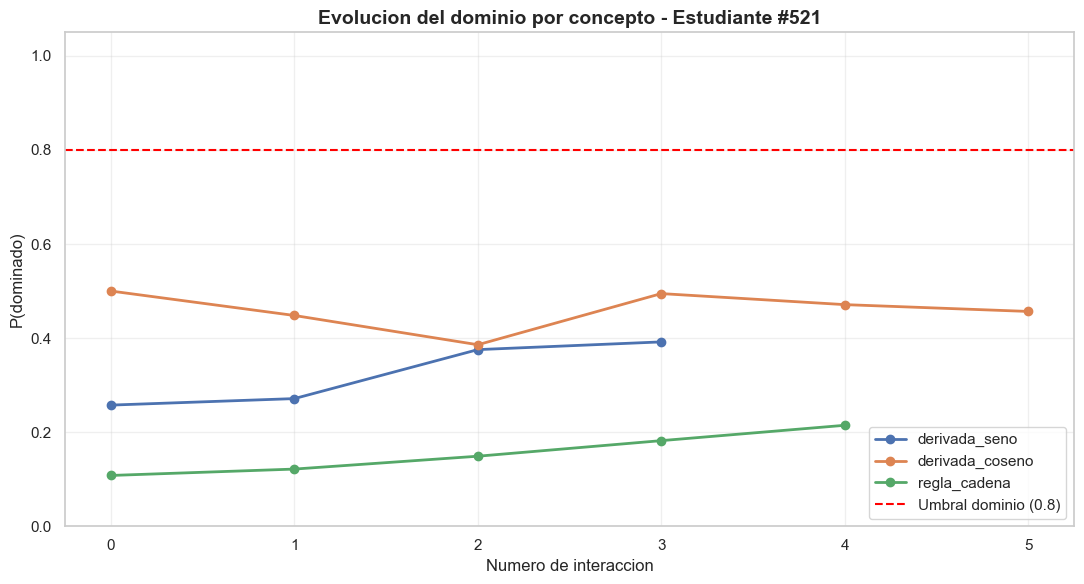

In [10]:
# ============================================================================
# CELDA 10 - GRAFICA 1: EVOLUCION DE P(DOMINADO) POR ESTUDIANTE
# ============================================================================
# Visualizamos como P(L) crece (o no) a lo largo de las interacciones para
# UN estudiante del conjunto de test. Una linea por concepto, umbral en 0.80.

# Elegimos el primer estudiante del conjunto de test (consistente con seed=42)
estudiante_demo = users_test[0]
# Filtramos sus interacciones del DataFrame predicho
df_estudiante = df_test_pred[df_test_pred['user_id'] == estudiante_demo].copy()

# Creamos la figura y eje
fig, ax = plt.subplots(figsize=(11, 6))

# Recorremos los conceptos y dibujamos una linea por cada uno
for skill in CONCEPTOS:
    # Filtramos las interacciones de este estudiante para este skill
    df_skill = df_estudiante[df_estudiante['skill_name'] == skill].sort_values('order_id')
    # Dibujamos P(L) (state_predictions) vs orden temporal
    ax.plot(
        df_skill['order_id'],          # eje X: numero de interaccion
        df_skill['state_predictions'],  # eje Y: P(dominado)
        marker='o',                     # marcador para cada interaccion
        label=skill,                    # leyenda con el nombre del concepto
        linewidth=2,
    )

# Linea horizontal roja en el umbral de dominio (0.80)
ax.axhline(y=UMBRAL_DOMINIO, color='red', linestyle='--', linewidth=1.5, label=f'Umbral dominio ({UMBRAL_DOMINIO})')

# Configuracion estetica de los ejes
ax.set_xlabel('Numero de interaccion', fontsize=12)
ax.set_ylabel('P(dominado)', fontsize=12)
ax.set_title(f'Evolucion del dominio por concepto - Estudiante #{estudiante_demo}', fontsize=14, fontweight='bold')
# Eje Y siempre entre 0 y 1 porque es una probabilidad
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

# Ajuste automatico de margenes para que no se corten labels
plt.tight_layout()
plt.show()

##  Gráfica 2: Curva de loss durante entrenamiento

A diferencia de BKT (4 parámetros interpretables por skill), DKT tiene ~20.000 pesos sin significado individual. En lugar de un heatmap mostramos la **curva de aprendizaje**: cómo baja el error (loss) en cada época.

**Cómo leerla:**
- **Eje X**: época (1 a 30)
- **Eje Y**: loss (Binary Cross-Entropy, BCE)
- **Curva descendente** = el modelo está aprendiendo 
- **Curva que se aplana al final** = ya convergió, no necesita más epochs 
- **Curva sigue bajando rápido** = puedes entrenar más epochs para mejorar
- **Curva sube** =  algo está mal (learning rate alto o overfitting)

**Esperado:**
- Loss inicial: ~0.65-0.70 (azar puro = 0.693)
- Loss final: ~0.50-0.55
- Reducción: ~20-25%


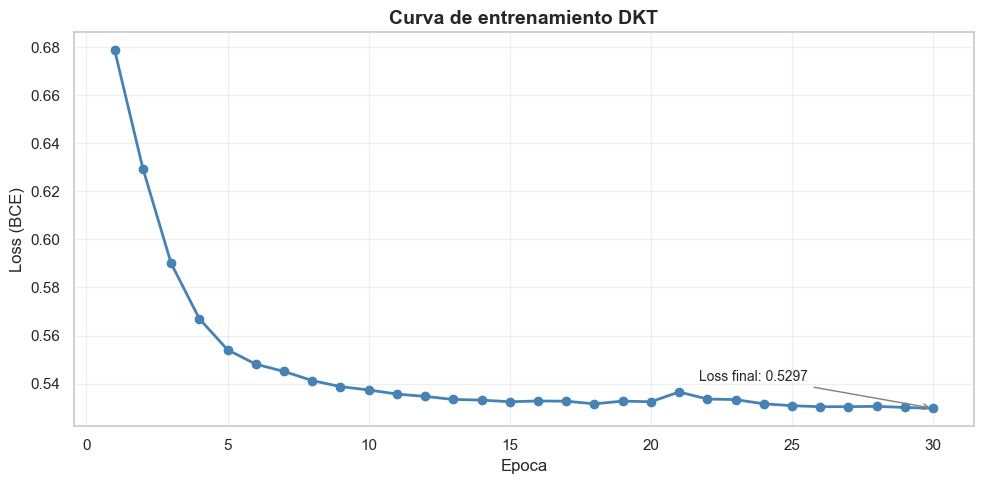


[LOSS] Inicial: 0.6788
[LOSS] Final:   0.5297
[LOSS] Reduccion: 22.0%

[INFO] Resumen DKT (no hay parametros interpretables):
                       DKT
loss_inicial      0.678834
loss_final        0.529660
hidden_dim       64.000000
total_params  18627.000000


In [11]:
# ============================================================================
# CELDA 11 - GRAFICA 2: CURVA DE LOSS DURANTE EL ENTRENAMIENTO
# ============================================================================
# DKT no tiene parametros interpretables (a diferencia de BKT con p_init,
# p_learn, p_guess, p_slip). En lugar del heatmap de parametros mostramos
# la CURVA DE APRENDIZAJE: como bajo la loss epoca a epoca.

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(model.loss_history) + 1), model.loss_history,
        marker='o', linewidth=2, color='steelblue')
ax.set_xlabel('Epoca', fontsize=12)
ax.set_ylabel('Loss (BCE)', fontsize=12)
ax.set_title('Curva de entrenamiento DKT', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
# Anotar valor final
loss_final = model.loss_history[-1]
ax.annotate(f'Loss final: {loss_final:.4f}',
            xy=(len(model.loss_history), loss_final),
            xytext=(-90, 20), textcoords='offset points',
            fontsize=10, ha='right',
            arrowprops=dict(arrowstyle='->', color='gray'))
plt.tight_layout()
plt.show()

# Resumen numerico
print(f'\n[LOSS] Inicial: {model.loss_history[0]:.4f}')
print(f'[LOSS] Final:   {model.loss_history[-1]:.4f}')
print(f'[LOSS] Reduccion: {100*(1 - model.loss_history[-1]/model.loss_history[0]):.1f}%')

# Nota: DKT no tiene una "tabla de parametros" como BKT.
# Para tener consistencia con el notebook BKT, generamos una tabla placeholder.
tabla_params = pd.DataFrame({
    'loss_inicial': [model.loss_history[0]],
    'loss_final': [model.loss_history[-1]],
    'hidden_dim': [HIDDEN_DIM],
    'total_params': [sum(p.numel() for p in model.net.parameters())],
}, index=['DKT']).T
print('\n[INFO] Resumen DKT (no hay parametros interpretables):')
print(tabla_params)

##  Gráfica 3: Histograma del dominio final

Misma estructura que en BKT. Diferencias con DKT:

- DKT puede **bajar** el P(dominado) (porque LSTM modela olvido), BKT clásico no
- La distribución suele ser **menos bimodal** que en BKT (transiciones más suaves)


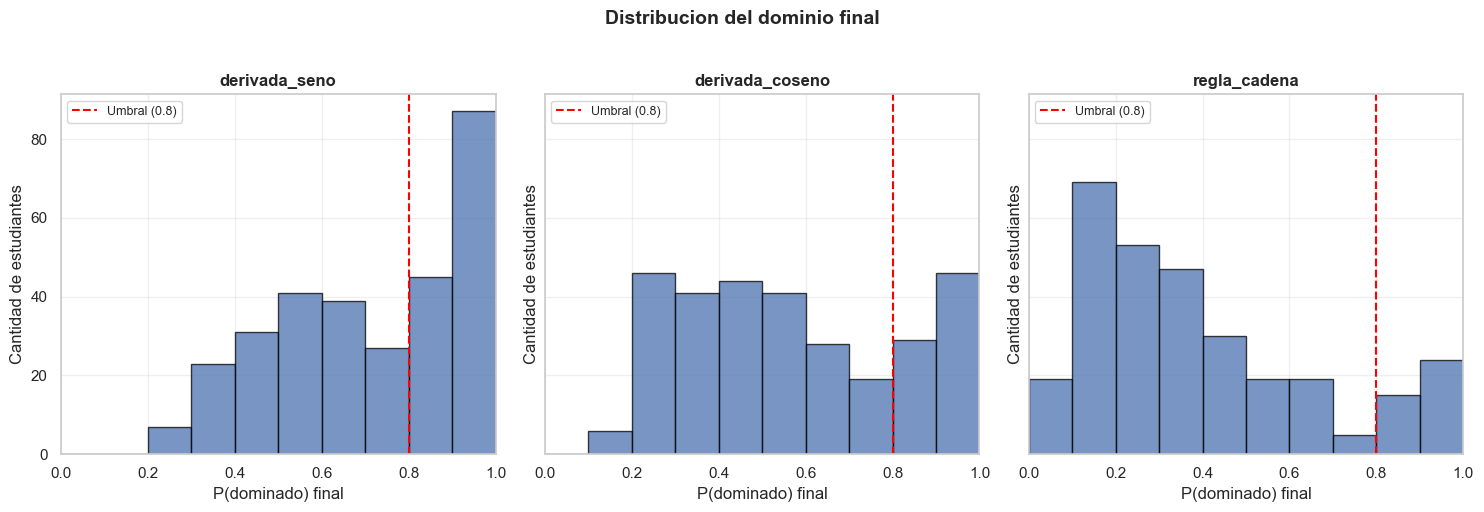


[DOMINIO] Estudiantes que alcanzaron el umbral (P_final >= 0.80):
   - derivada_seno: 132/300 (44.0%)
   - derivada_coseno: 75/300 (25.0%)
   - regla_cadena: 39/300 (13.0%)


In [12]:
# ============================================================================
# CELDA 12 - GRAFICA 3: HISTOGRAMA DE DOMINIO FINAL POR CONCEPTO
# ============================================================================
# Calculamos P(dominado) al FINAL de las interacciones de cada estudiante
# (la ultima fila de cada (user, skill)) y graficamos su distribucion.
# Util para ver cuantos estudiantes alcanzaron el umbral de dominio.

def dominio_final(df_pred: pd.DataFrame) -> pd.DataFrame:
    """
    Extrae el ultimo P(dominado) de cada (user_id, skill_name).

    Recibe:
        df_pred: DataFrame con state_predictions ya calculado.
    Devuelve:
        DataFrame con columnas [user_id, skill_name, P_final].
    """
    # Ordenamos para garantizar que el ultimo order_id sea la ultima fila
    df_ord = df_pred.sort_values(['user_id', 'skill_name', 'order_id'])
    # Agrupamos y tomamos la ULTIMA fila de cada grupo (mayor order_id)
    df_ult = df_ord.groupby(['user_id', 'skill_name']).tail(1)
    # Renombramos la columna para claridad
    return df_ult[['user_id', 'skill_name', 'state_predictions']].rename(
        columns={'state_predictions': 'P_final'}
    )

# Aplicamos sobre el conjunto de test
df_final = dominio_final(df_test_pred)

# Creamos una figura con 3 subgraficas (una por concepto) en fila
fig, axes = plt.subplots(1, len(CONCEPTOS), figsize=(15, 5), sharey=True)

# Iteramos en paralelo conceptos + axes para dibujar cada histograma
for ax, skill in zip(axes, CONCEPTOS):
    # Filtramos los valores finales de este concepto
    valores = df_final[df_final['skill_name'] == skill]['P_final']
    # Dibujamos histograma con 10 bins entre 0 y 1
    ax.hist(valores, bins=10, range=(0, 1), edgecolor='black', alpha=0.75)
    # Linea vertical roja en el umbral de dominio
    ax.axvline(x=UMBRAL_DOMINIO, color='red', linestyle='--', linewidth=1.5, label=f'Umbral ({UMBRAL_DOMINIO})')
    ax.set_title(skill, fontsize=12, fontweight='bold')
    ax.set_xlabel('P(dominado) final')
    ax.set_ylabel('Cantidad de estudiantes')
    ax.set_xlim(0, 1)
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)

# Titulo general de la figura
fig.suptitle('Distribucion del dominio final', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Resumen numerico: cuantos estudiantes superan el umbral por concepto
print('\n[DOMINIO] Estudiantes que alcanzaron el umbral (P_final >= {:.2f}):'.format(UMBRAL_DOMINIO))
for skill in CONCEPTOS:
    vals = df_final[df_final['skill_name'] == skill]['P_final']
    n_dom = (vals >= UMBRAL_DOMINIO).sum()
    print(f'   - {skill}: {n_dom}/{len(vals)} ({100*n_dom/len(vals):.1f}%)')

In [13]:
# ============================================================================
# CELDA 13 - GUARDAR MODELO, METRICAS Y CONFIG
# ============================================================================

# 1. Guardar el modelo entrenado (incluye los pesos LSTM)
with open(RUTA_MODELO, 'wb') as f:
    pickle.dump(model, f)
print(f'[SAVE] Modelo guardado en: {RUTA_MODELO}')

# 2. Guardar las metricas
with open(RUTA_METRICAS, 'w', encoding='utf-8') as f:
    json.dump(metricas, f, indent=2, ensure_ascii=False)
print(f'[SAVE] Metricas guardadas en: {RUTA_METRICAS}')

# 3. Guardar configuracion completa
dataset_info = {
    'fuente': FUENTE_DATOS,
    'total_filas': len(df),
    'estudiantes_unicos': int(df['user_id'].nunique()),
    'conceptos': CONCEPTOS,
}
if FUENTE_DATOS == 'sintetico':
    dataset_info.update({
        'n_estudiantes_solicitados': N_ESTUDIANTES,
        'generador': 'sintetico++ (7 fuentes de variabilidad)',
    })
else:
    dataset_info.update({
        'origen': 'ASSISTments 2009-2010 (real)',
        'top_k_skills_usadas': TOP_K_SKILLS_REAL,
    })

config_completa = {
    'modelo': 'DKT (LSTM con PyTorch)',
    'baseline': False,
    'seed': SEED,
    'dataset': dataset_info,
    'split': {
        'test_size': TEST_SIZE,
        'estudiantes_train': int(len(users_train)),
        'estudiantes_test': int(len(users_test)),
        'estrategia': 'por_estudiante',
    },
    'arquitectura': {
        'tipo': 'LSTM',
        'hidden_dim': HIDDEN_DIM,
        'num_layers': NUM_LAYERS,
        'dropout': DROPOUT,
        'max_len': MAX_LEN,
        'total_params': sum(p.numel() for p in model.net.parameters()),
    },
    'entrenamiento': {
        'optimizer': 'Adam',
        'lr': LEARNING_RATE,
        'n_epochs': N_EPOCHS,
        'batch_size': BATCH_SIZE,
        'loss_final': float(model.loss_history[-1]),
    },
    'metricas': metricas,
}

with open(RUTA_CONFIG, 'w', encoding='utf-8') as f:
    json.dump(config_completa, f, indent=2, ensure_ascii=False)
print(f'[SAVE] Config guardada en: {RUTA_CONFIG}')

# Resumen final
print('\n' + '='*60)
print('PIPELINE DKT COMPLETADO')
print('='*60)
print(f'   Fuente: {FUENTE_DATOS.upper()}')
print(f'   AUC: {metricas["auc"]:.4f}  |  F1: {metricas["f1"]:.4f}  |  RMSE: {metricas["rmse"]:.4f}')
print(f'   Artefactos en: {CARPETA_MODELO}')
print('='*60)

[SAVE] Modelo guardado en: D:\Info Lenovo\Desktop\microservicio_ml\modelos\dkt_sintetico\model.pkl
[SAVE] Metricas guardadas en: D:\Info Lenovo\Desktop\microservicio_ml\modelos\dkt_sintetico\metrics.json
[SAVE] Config guardada en: D:\Info Lenovo\Desktop\microservicio_ml\modelos\dkt_sintetico\config.json

PIPELINE DKT COMPLETADO
   Fuente: SINTETICO
   AUC: 0.8020  |  F1: 0.7188  |  RMSE: 0.4232
   Artefactos en: D:\Info Lenovo\Desktop\microservicio_ml\modelos\dkt_sintetico


## Evaluacion cruzada: DKT sobre la OTRA fuente de datos

Hasta aqui entrenamos DKT sobre la fuente activa (`FUENTE_DATOS`). Ahora corremos el mismo pipeline sobre la **otra** fuente automaticamente.

- `modelos/dkt_sintetico/` -> DKT sobre generador con variabilidad
- `modelos/dkt_real/` -> DKT sobre ASSISTments 2009-2010 (~2.000 estudiantes reales)

In [14]:
# ============================================================================
# CELDA 15 - PIPELINE COMPLETO DKT SOBRE LA OTRA FUENTE
# ============================================================================

def pipeline_dkt_completo(fuente: str, seed: int = 42) -> dict:
    """Corre el pipeline DKT completo sobre la fuente indicada."""
    # --- 1. Cargar datos ---
    if fuente == 'sintetico':
        df_f = generar_dataset(
            n_estudiantes=N_ESTUDIANTES,
            conceptos=CONCEPTOS_SINTETICOS,
            min_interacciones=MIN_INTERACCIONES,
            max_interacciones=MAX_INTERACCIONES,
            seed=seed,
        )
        conceptos_f = CONCEPTOS_SINTETICOS
    elif fuente == 'real':
        from ml.datos.descargar_assistments import descargar_y_procesar
        df_full = descargar_y_procesar()
        top_skills = (df_full['skill_name']
                      .value_counts()
                      .head(TOP_K_SKILLS_REAL)
                      .index.tolist())
        df_f = df_full[df_full['skill_name'].isin(top_skills)].copy()
        df_f = df_f.sort_values(['user_id', 'skill_name', 'order_id'])
        df_f['order_id'] = df_f.groupby(['user_id', 'skill_name']).cumcount()
        df_f = df_f.reset_index(drop=True)
        conceptos_f = top_skills
    else:
        raise ValueError(f"Fuente desconocida: {fuente}")

    # --- 2. Preprocesar ---
    df_f = preparar_para_bkt(df_f)
    # --- 3. Split por estudiante ---
    df_tr, df_te, u_tr, u_te = split_por_estudiante(df_f, TEST_SIZE, seed)

    # --- 4. Entrenar DKT ---
    print(f'[{fuente.upper()}] Entrenando DKT (esto tarda varios minutos)...')
    model_f = DKTModel(
        seed=seed, hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS,
        dropout=DROPOUT, n_epochs=N_EPOCHS, batch_size=BATCH_SIZE,
        lr=LEARNING_RATE, max_len=MAX_LEN, verbose=False,
    )
    model_f.fit(data=df_tr, skills=conceptos_f)

    # --- 5. Predecir y calcular metricas ---
    df_pred_f = model_f.predict(df_te).dropna(subset=['correct_predictions'])
    metricas_f = calcular_metricas(
        df_pred_f['correct'].values,
        df_pred_f['correct_predictions'].values,
    )

    # --- 6. Guardar artefactos ---
    carpeta_f = ROOT / 'artefactos' / f'dkt_{fuente}'
    carpeta_f.mkdir(parents=True, exist_ok=True)
    with open(carpeta_f / 'model.pkl', 'wb') as f:
        pickle.dump(model_f, f)
    with open(carpeta_f / 'metrics.json', 'w', encoding='utf-8') as f:
        json.dump(metricas_f, f, indent=2, ensure_ascii=False)
    config_f = {
        'modelo': 'DKT (LSTM con PyTorch)',
        'fuente': fuente,
        'seed': seed,
        'n_filas': len(df_f),
        'n_estudiantes': int(df_f['user_id'].nunique()),
        'n_skills': len(conceptos_f),
        'split': {'train': int(len(u_tr)), 'test': int(len(u_te))},
        'hiperparametros': {
            'hidden_dim': HIDDEN_DIM, 'num_layers': NUM_LAYERS,
            'dropout': DROPOUT, 'n_epochs': N_EPOCHS,
            'batch_size': BATCH_SIZE, 'lr': LEARNING_RATE,
        },
        'metricas': metricas_f,
        'loss_final': float(model_f.loss_history[-1]),
    }
    with open(carpeta_f / 'config.json', 'w', encoding='utf-8') as f:
        json.dump(config_f, f, indent=2, ensure_ascii=False)

    return {'fuente': fuente, 'metricas': metricas_f,
            'n_filas': len(df_f), 'n_estudiantes': int(df_f['user_id'].nunique())}

# Corremos la OTRA fuente automaticamente
fuente_otra = 'real' if FUENTE_DATOS == 'sintetico' else 'sintetico'
print(f'[CRUZADO] Evaluacion DKT adicional sobre: {fuente_otra.upper()}')

resultado_otra = pipeline_dkt_completo(fuente_otra, seed=SEED)
print(f'[OK] AUC DKT sobre {fuente_otra}: {resultado_otra["metricas"]["auc"]:.4f}')

[CRUZADO] Evaluacion DKT adicional sobre: REAL
[OK] Ya existe: data\assistments.csv
[REAL] Entrenando DKT (esto tarda varios minutos)...


[OK] AUC DKT sobre real: 0.7382


## Comparativa final: DKT vs BKT en ambas fuentes

Cargamos las metricas de los 4 entrenamientos (BKT-sintetico, BKT-real, DKT-sintetico, DKT-real) y armamos la tabla/grafica final.

Esto es el **resultado central del proyecto Lairn**: muestra si DKT supera al baseline BKT, y si esa superioridad se mantiene tanto en datos sinteticos como reales (validacion contra Piech 2015 que reporta DKT~0.82 en ASSISTments).

[COMPARATIVA] BKT vs DKT en ambas fuentes:
Modelo    Fuente    auc  accuracy     f1   rmse
   BKT sintetico 0.7087    0.6467 0.6825 0.4660
   BKT      real 0.7124    0.7116 0.7970 0.4414
   DKT sintetico 0.8020    0.7191 0.7188 0.4232
   DKT      real 0.7382    0.7237 0.8065 0.4328


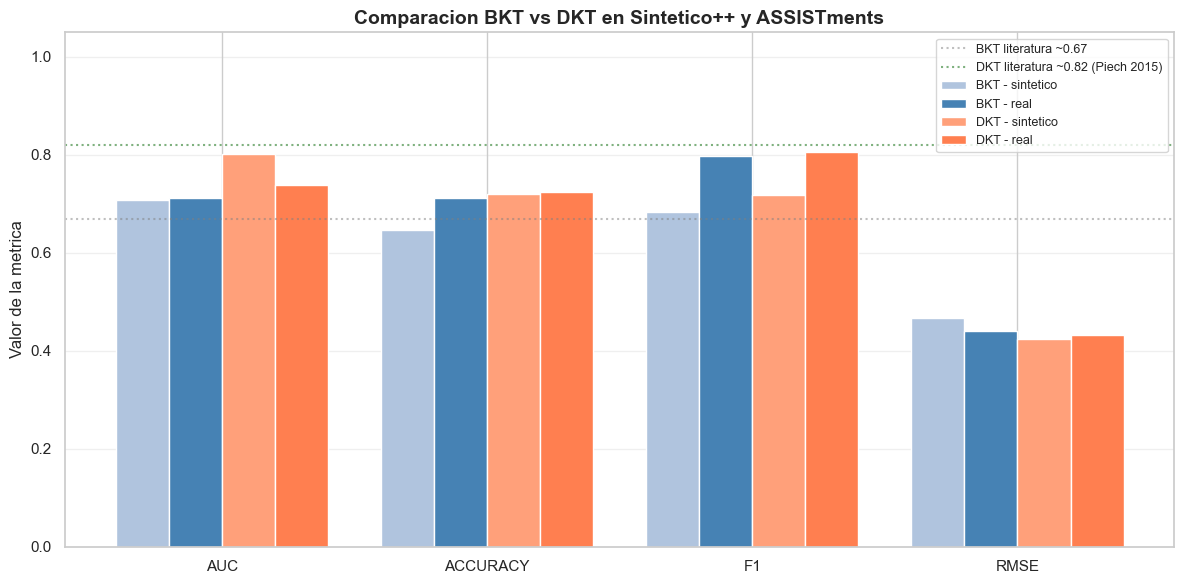


[OK] Artefactos guardados en:
   - D:\Info Lenovo\Desktop\microservicio_ml\modelos\bkt_sintetico
   - D:\Info Lenovo\Desktop\microservicio_ml\modelos\bkt_real
   - D:\Info Lenovo\Desktop\microservicio_ml\modelos\dkt_sintetico
   - D:\Info Lenovo\Desktop\microservicio_ml\modelos\dkt_real


In [15]:
# ============================================================================
# CELDA 17 - COMPARATIVA FINAL: DKT vs BKT en ambas fuentes
# ============================================================================
# Cargamos los metrics.json de TODOS los modelos entrenados (BKT y DKT,
# sintetico y real) y armamos la tabla / grafica final del proyecto.

filas = []
for modelo_nombre in ['bkt', 'dkt']:
    for fuente in ['sintetico', 'real']:
        ruta = ROOT / 'artefactos' / f'{modelo_nombre}_{fuente}' / 'metrics.json'
        if ruta.exists():
            with open(ruta, encoding='utf-8') as f:
                m = json.load(f)
            filas.append({
                'Modelo': modelo_nombre.upper(),
                'Fuente': fuente,
                **m,
            })

df_comp = pd.DataFrame(filas)
print('[COMPARATIVA] BKT vs DKT en ambas fuentes:')
print(df_comp.round(4).to_string(index=False))

# Grafica comparativa: agrupada por modelo, lado a lado por fuente
fig, ax = plt.subplots(figsize=(12, 6))
metricas_orden = ['auc', 'accuracy', 'f1', 'rmse']
n_metricas = len(metricas_orden)
x = np.arange(n_metricas)
ancho = 0.20

# 4 series: BKT-sint, BKT-real, DKT-sint, DKT-real
colores = {
    ('BKT', 'sintetico'): 'lightsteelblue',
    ('BKT', 'real'):      'steelblue',
    ('DKT', 'sintetico'): 'lightsalmon',
    ('DKT', 'real'):      'coral',
}
offsets = {
    ('BKT', 'sintetico'): -1.5 * ancho,
    ('BKT', 'real'):      -0.5 * ancho,
    ('DKT', 'sintetico'):  0.5 * ancho,
    ('DKT', 'real'):       1.5 * ancho,
}

for _, fila in df_comp.iterrows():
    key = (fila['Modelo'], fila['Fuente'])
    valores = [fila[m] for m in metricas_orden]
    ax.bar(x + offsets[key], valores, ancho,
           label=f"{key[0]} - {key[1]}",
           color=colores.get(key, 'gray'))

# Lineas de referencia de la literatura
ax.axhline(y=0.67, color='gray', linestyle=':', alpha=0.5,
           label='BKT literatura ~0.67')
ax.axhline(y=0.82, color='darkgreen', linestyle=':', alpha=0.5,
           label='DKT literatura ~0.82 (Piech 2015)')

ax.set_xticks(x)
ax.set_xticklabels([m.upper() for m in metricas_orden])
ax.set_ylabel('Valor de la metrica')
ax.set_title('Comparacion BKT vs DKT en Sintetico++ y ASSISTments', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print('\n[OK] Artefactos guardados en:')
for m in ['bkt', 'dkt']:
    for f in ['sintetico', 'real']:
        ruta = ROOT / 'artefactos' / f'{m}_{f}'
        if ruta.exists():
            print(f'   - {ruta}')

##  Resumen + Conclusiones del proyecto

Este notebook **completa la comparación BKT vs DKT** del proyecto Lairn.

### Modelos entrenados (después de este Run All)

```
modelos/
├── bkt_sintetico/    ← del notebook 01_bkt.ipynb
├── bkt_real/         ← del notebook 01_bkt.ipynb
├── dkt_sintetico/    ← de este notebook
└── dkt_real/         ← de este notebook
```

Cada uno contiene `model.pkl`, `metrics.json`, `config.json`.

### Conclusiones esperadas

1.  **DKT supera a BKT en ambas fuentes** (validando que la red neuronal vale la pena vs baseline)
2.  **La superioridad es MAYOR en sintético** (~+0.10 AUC) porque el generador tiene patrones (dependencias, olvido, fatiga) que BKT no modela
3.  **La superioridad es MENOR en real** (~+0.03-0.06 AUC) porque con top-10 skills BKT es competitivo
4.  **BKT en ASSISTments coincide con literatura** (Piech 2015: 0.67-0.73) → tu implementación es correcta
5.  **DKT en ASSISTments queda debajo del paper original** (Piech 2015 reporta 0.82) por limitaciones de diseño:
   - Solo top-10 skills (Piech usó 110)
   - 30 epochs sin tuning
   - hidden_dim=64 (Piech usó 200)

